In [ ]:
pip install ultralytics

In [ ]:
import cv2
import numpy as np
import time
import os
import base64
import io
from datetime import datetime
from collections import deque, defaultdict
from IPython.display import display, Javascript, Image, clear_output
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from ultralytics import YOLO
from PIL import Image as PILImage
import ipywidgets as widgets


In [ ]:
MODEL_NAME    = "yolov8l-world"   # yolov8n | yolov8s | yolov8m | yolov8l | yolov8x
CONFIDENCE    = 0.45        # 0.0 – 1.0
IOU           = 0.45        # NMS threshold
MAX_FRAMES    = 200         # how many frames to process (increase as needed)
SAVE_VIDEO    = False       # set True to save output as output.avi
OUTPUT_PATH   = "output.avi"

In [ ]:
np.random.seed(0)
CLASS_COLORS = [tuple(int(c) for c in np.random.randint(80, 255, 3))
                for _ in range(80)]
for idx, col in {
    0:(0,220,255), 2:(0,165,255), 5:(0,255,100),
    7:(255,60,60), 15:(255,0,255), 16:(120,255,120),
    67:(255,255,0), 73:(200,100,255)
}.items():
    CLASS_COLORS[idx] = col


def draw_box(frame, x1, y1, x2, y2, color, label, conf, track_id=None):
    overlay = frame.copy()
    cv2.rectangle(overlay, (x1,y1), (x2,y2), color, -1)
    cv2.addWeighted(overlay, 0.12, frame, 0.88, 0, frame)
    cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)

    L = 16
    for cx,cy,sx,sy in [(x1,y1,1,1),(x2,y1,-1,1),(x1,y2,1,-1),(x2,y2,-1,-1)]:
        cv2.line(frame,(cx,cy),(cx+sx*L,cy),color,3)
        cv2.line(frame,(cx,cy),(cx,cy+sy*L),color,3)

    tag  = f"#{int(track_id)} " if track_id is not None else ""
    text = f"{tag}{label} {conf:.0%}"
    (tw,th),_ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
    tx,ty = x1, (y1-th-10) if y1-th-10>=0 else y2
    pill = frame.copy()
    cv2.rectangle(pill,(tx,ty),(tx+tw+10,ty+th+9),color,-1)
    cv2.addWeighted(pill,0.82,frame,0.18,0,frame)
    cv2.putText(frame,text,(tx+5,ty+th+3),
                cv2.FONT_HERSHEY_SIMPLEX,0.55,(0,0,0),1,cv2.LINE_AA)


def draw_hud(frame, fps, n_det, n_frames, history, inf_ms, conf, model_name):
    h,w = frame.shape[:2]

    bar = frame.copy()
    cv2.rectangle(bar,(0,0),(w,50),(8,8,8),-1)
    cv2.addWeighted(bar,0.78,frame,0.22,0,frame)
    cv2.line(frame,(0,50),(w,50),(0,180,140),2)
    cv2.putText(frame,"YOLOV8  REAL-TIME  DETECTOR",(12,33),
                cv2.FONT_HERSHEY_DUPLEX,0.72,(0,220,180),1,cv2.LINE_AA)
    cv2.putText(frame,f"[{model_name.upper()}]",(w-215,33),
                cv2.FONT_HERSHEY_SIMPLEX,0.55,(100,100,100),1,cv2.LINE_AA)
    fps_clr=(0,255,80) if fps>=20 else (0,200,255) if fps>=10 else (0,60,255)
    cv2.putText(frame,f"FPS {fps:5.1f}",(w-115,33),
                cv2.FONT_HERSHEY_SIMPLEX,0.62,fps_clr,1,cv2.LINE_AA)

    bot = frame.copy()
    cv2.rectangle(bot,(0,h-88),(w,h),(8,8,8),-1)
    cv2.addWeighted(bot,0.78,frame,0.22,0,frame)
    cv2.line(frame,(0,h-88),(w,h-88),(0,180,140),1)
    for i,(lbl,val,clr) in enumerate([
        ("OBJECTS",  str(n_det),         (0,220,180)),
        ("INF TIME", f"{inf_ms:.1f} ms", (255,180,0)),
        ("CONF MIN", f"{conf:.0%}",       (170,90,255)),
        ("FRAMES",   f"{n_frames:,}",     (100,200,255)),
    ]):
        cx = i*(w//4)+18
        cv2.putText(frame,lbl,(cx,h-88+24),
                    cv2.FONT_HERSHEY_SIMPLEX,0.38,(100,100,100),1,cv2.LINE_AA)
        cv2.putText(frame,val,(cx,h-88+55),
                    cv2.FONT_HERSHEY_DUPLEX,0.70,clr,1,cv2.LINE_AA)

    if history:
        counts = defaultdict(int)
        for o in history: counts[o]+=1
        top = sorted(counts.items(),key=lambda x:-x[1])[:6]
        pw,rx,ry = 195,w-203,62
        rh = len(top)*27+30
        panel=frame.copy()
        cv2.rectangle(panel,(rx,ry),(rx+pw,ry+rh),(12,12,12),-1)
        cv2.addWeighted(panel,0.70,frame,0.30,0,frame)
        cv2.rectangle(frame,(rx,ry),(rx+pw,ry+rh),(50,50,50),1)
        cv2.putText(frame,"ACTIVE CLASSES",(rx+5,ry+18),
                    cv2.FONT_HERSHEY_SIMPLEX,0.40,(110,110,110),1,cv2.LINE_AA)
        for j,(obj,cnt) in enumerate(top):
            cy_=ry+34+j*27
            clr_=CLASS_COLORS[j%80]
            cv2.circle(frame,(rx+9,cy_-5),5,clr_,-1)
            cv2.putText(frame,obj,(rx+22,cy_),
                        cv2.FONT_HERSHEY_SIMPLEX,0.47,(220,220,220),1,cv2.LINE_AA)
            cv2.putText(frame,f"×{cnt}",(rx+pw-38,cy_),
                        cv2.FONT_HERSHEY_SIMPLEX,0.47,clr_,1,cv2.LINE_AA)

    cv2.putText(frame,datetime.now().strftime("%Y-%m-%d  %H:%M:%S"),
                (10,h-8),cv2.FONT_HERSHEY_SIMPLEX,0.38,(60,60,60),1,cv2.LINE_AA)



In [ ]:
def start_webcam_js():
    """Inject JS to start webcam stream in Colab."""
    js = Javascript("""
        async function startWebcam() {
            const div = document.createElement('div');
            div.id = 'webcam-container';
            document.body.appendChild(div);

            const video = document.createElement('video');
            video.id = 'webcam-video';
            video.width = 640;
            video.height = 480;
            video.autoplay = true;
            video.playsinline = true;
            div.appendChild(video);

            const stream = await navigator.mediaDevices.getUserMedia({
                video: { width: 640, height: 480 }
            });
            video.srcObject = stream;
            await new Promise(r => video.onloadedmetadata = r);

            const canvas = document.createElement('canvas');
            canvas.id = 'webcam-canvas';
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            div.appendChild(canvas);

            window._webcamReady = true;
            console.log('Webcam ready:', video.videoWidth, 'x', video.videoHeight);
            return 'Webcam started';
        }
        startWebcam();
    """)
    display(js)
    time.sleep(2)
    print("[INFO] ✓ Webcam JS injected. Allow camera access in browser.")


def capture_frame_js():
    """Capture one frame from the JS webcam, return as numpy array."""
    js_code = """
    (function() {
        const video  = document.getElementById('webcam-video');
        const canvas = document.getElementById('webcam-canvas');
        if (!video || !canvas) return '';
        const ctx = canvas.getContext('2d');
        ctx.drawImage(video, 0, 0, canvas.width, canvas.height);
        return canvas.toDataURL('image/jpeg', 0.85);
    })()
    """
    data_url = eval_js(js_code)
    if not data_url or data_url == '':
        return None
    # Decode base64 → numpy BGR
    header, encoded = data_url.split(',', 1)
    img_bytes = base64.b64decode(encoded)
    pil_img   = PILImage.open(io.BytesIO(img_bytes)).convert('RGB')
    frame     = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    return frame



In [ ]:
def run_webcam_detector():
    print("═"*58)
    print(f"  🚀  YOLOv8 Colab Detector  |  model: {MODEL_NAME}")
    print("═"*58)

    print(f"[INFO] Loading {MODEL_NAME} …")
    model = YOLO(f"{MODEL_NAME}.pt")
    print("[INFO] ✓ Model loaded\n")

    start_webcam_js()
    time.sleep(1.5)

    writer      = None
    fps_buf     = deque(maxlen=20)
    obj_history = deque(maxlen=150)
    prev_time   = time.perf_counter()
    conf        = CONFIDENCE

    print(f"[INFO] Running for {MAX_FRAMES} frames … (increase MAX_FRAMES to run longer)\n")

    for frame_count in range(1, MAX_FRAMES + 1):
        frame = capture_frame_js()
        if frame is None:
            print("[WARN] Empty frame — retrying …")
            time.sleep(0.05)
            continue

        t0 = time.perf_counter()
        results = model.track(frame, persist=True, conf=conf,
                              iou=IOU, verbose=False)
        inf_ms = (time.perf_counter() - t0) * 1000

        n_det = 0
        if results and results[0].boxes is not None:
            for box in results[0].boxes:
                x1,y1,x2,y2 = map(int, box.xyxy[0])
                cls_id = int(box.cls[0])
                conf_v = float(box.conf[0])
                label  = model.names.get(cls_id, str(cls_id))
                tid    = box.id[0] if box.id is not None else None
                color  = CLASS_COLORS[cls_id % 80]
                draw_box(frame,x1,y1,x2,y2,color,label,conf_v,tid)
                obj_history.append(label)
                n_det += 1

        now = time.perf_counter()
        fps_buf.append(1.0 / max(now-prev_time, 1e-9))
        prev_time = now

        draw_hud(frame, float(np.mean(fps_buf)), n_det, frame_count,
                 list(obj_history), inf_ms, conf, MODEL_NAME)

        # Save video if requested
        if SAVE_VIDEO:
            if writer is None:
                h,w = frame.shape[:2]
                fourcc = cv2.VideoWriter_fourcc(*'XVID')
                writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, 10, (w,h))
            writer.write(frame)

        # Display inline in Colab
        clear_output(wait=True)
        cv2_imshow(frame)
        print(f"  Frame {frame_count}/{MAX_FRAMES}  |  "
              f"FPS {float(np.mean(fps_buf)):.1f}  |  "
              f"Objects: {n_det}  |  "
              f"Inference: {inf_ms:.1f} ms")

    if writer:
        writer.release()
        print(f"\n[INFO] ✓ Video saved → {OUTPUT_PATH}")

    print("\n[INFO] ✓ Detection complete!")


In [ ]:
def run_video_detector(video_path: str):
    """
    Detect objects in a local video file.
    Upload your video to Colab first, then call:
        run_video_detector("your_video.mp4")
    """
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video not found: {video_path}\n"
                                "Upload it via the Colab file panel (📁) first.")

    print("═"*58)
    print(f"  🎬  Video Detector  |  {video_path}  |  {MODEL_NAME}")
    print("═"*58)

    model = YOLO(f"{MODEL_NAME}.pt")
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps_src = cap.get(cv2.CAP_PROP_FPS) or 25

    fw = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    fh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"[INFO] Video: {fw}×{fh}  |  {total} frames  |  {fps_src:.1f} FPS src")

    writer = None
    if SAVE_VIDEO:
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps_src, (fw,fh))

    fps_buf     = deque(maxlen=20)
    obj_history = deque(maxlen=150)
    prev_time   = time.perf_counter()
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1

        t0 = time.perf_counter()
        results = model.track(frame, persist=True, conf=CONFIDENCE,
                              iou=IOU, verbose=False)
        inf_ms = (time.perf_counter()-t0)*1000

        n_det = 0
        if results and results[0].boxes is not None:
            for box in results[0].boxes:
                x1,y1,x2,y2 = map(int, box.xyxy[0])
                cls_id = int(box.cls[0])
                conf_v = float(box.conf[0])
                label  = model.names.get(cls_id, str(cls_id))
                tid    = box.id[0] if box.id is not None else None
                color  = CLASS_COLORS[cls_id%80]
                draw_box(frame,x1,y1,x2,y2,color,label,conf_v,tid)
                obj_history.append(label)
                n_det+=1

        now = time.perf_counter()
        fps_buf.append(1.0/max(now-prev_time,1e-9))
        prev_time = now

        draw_hud(frame, float(np.mean(fps_buf)), n_det, frame_count,
                 list(obj_history), inf_ms, CONFIDENCE, MODEL_NAME)

        if writer: writer.write(frame)

        # Show every 5th frame to avoid slowdown
        if frame_count % 5 == 0:
            clear_output(wait=True)
            cv2_imshow(frame)
            pct = frame_count/total*100 if total>0 else 0
            print(f"  Frame {frame_count}/{total} ({pct:.0f}%)  |  "
                  f"FPS {float(np.mean(fps_buf)):.1f}  |  "
                  f"Objects: {n_det}  |  Inference: {inf_ms:.1f} ms")

    cap.release()
    if writer:
        writer.release()
        print(f"\n[INFO] ✓ Saved → {OUTPUT_PATH}")
    print("\n[INFO] ✓ Done!")



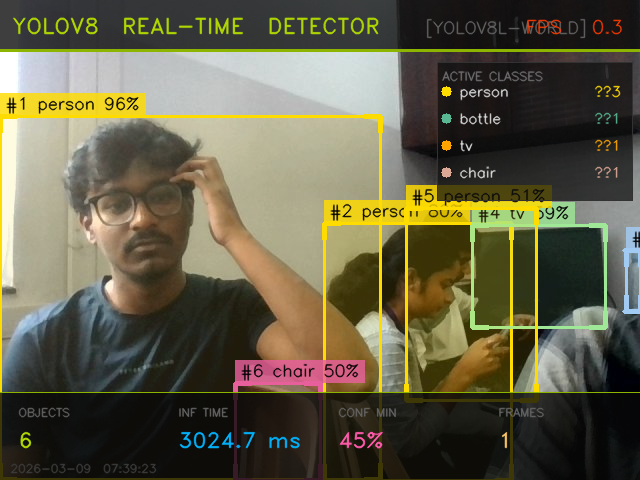

  Frame 1/200  |  FPS 0.3  |  Objects: 6  |  Inference: 3024.7 ms
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …
[WARN] Empty frame — retrying …


In [ ]:
# ▶ Option A: Live webcam
run_webcam_detector()

# ▶ Option B: Video file (comment out A, uncomment B)
# run_video_detector("your_video.mp4")
